REGIONES Y FRONTERAS 

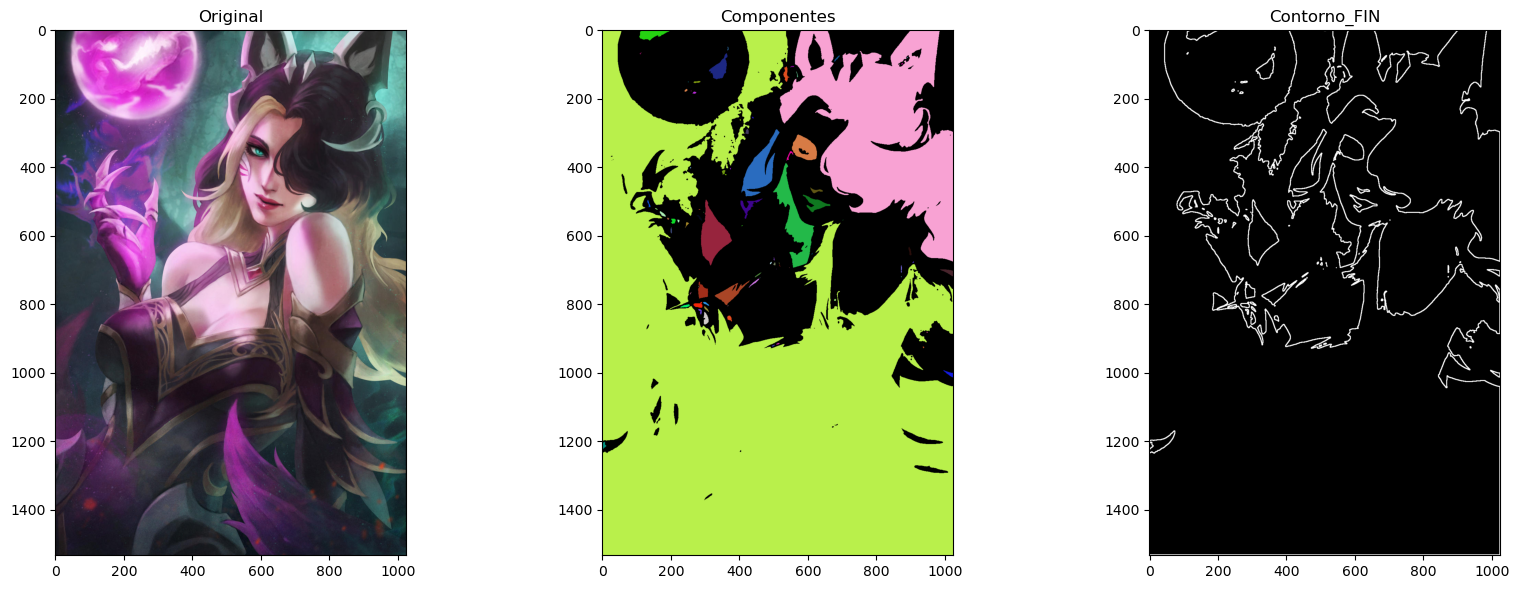

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('AHRI.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (7, 7), 0)

_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
num_l, label = cv2.connectedComponents(binary)

color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)
color[0] = [0, 0, 0] 
colorear = color[label]
contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

plt.figure(figsize=(20, 15))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(2, 3, 2)
plt.imshow(colorear)
plt.title("Componentes")

plt.subplot(2, 3, 3)
plt.imshow(contorno_fin,cmap='gray')
plt.title("Contorno_FIN")

plt.show()

CONTEO

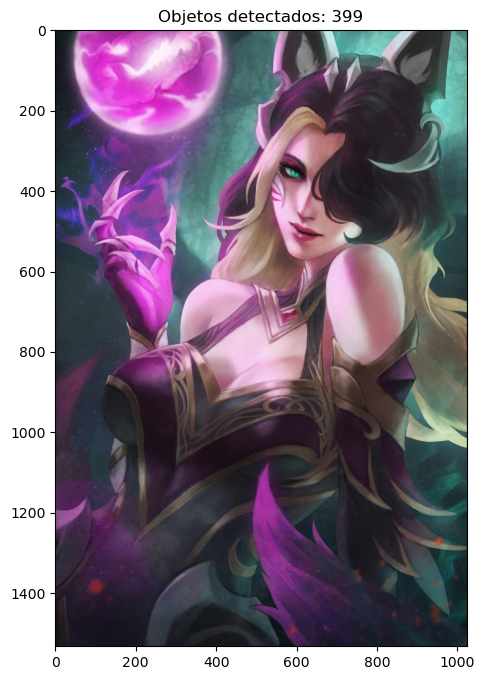

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    e_img = measure.label(binary, connectivity=2)  # conectividad 8
    num_obj = np.max(e_img)
    return num_obj

# Cargar imagen
imagen = cv2.imread('ahri.jpg')

# Contar elementos
num = contar_elementos(imagen)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title(f"Objetos detectados: {num}")
plt.show()

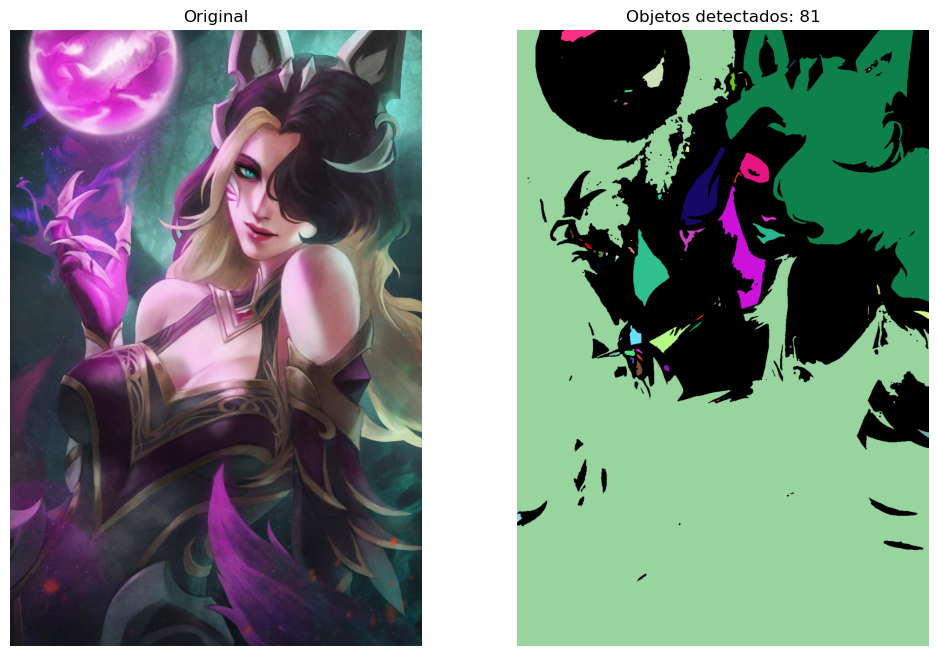

Objetos detectados: 81


In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('AHRI.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7, 7), 0)

_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

num_labels, labels = cv2.connectedComponents(binary)
num_objetos = num_labels - 1

colors = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
colors[0] = [0, 0, 0]

colored_img = colors[labels]

plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(colored_img)
plt.title(f"Objetos detectados: {num_objetos}")
plt.axis("off")

plt.show()

print("Objetos detectados:", num_objetos)